## Imports

In [17]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import keras
import matplotlib.pyplot as plt


In [2]:
# read in and explore data
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
# make the requests using requests api to avoid 403 error
r = requests.get(url, headers=headers)
# read page text, wrap with StringIO to serve as in memory file for read_html api
tables = pd.read_html(StringIO(r.text))
# extract snp 500 companies
snp = tables[0]
it_sector = snp[snp['GICS Sector'] == 'Information Technology']

# function to extract market cap from yf
def getMarketCap(tkr):
    stock = yf.Ticker(tkr)
    info = stock.info
    return info.get('marketCap')

# append a column for market cap and remove NaN entries
it_sector.loc[:, "marketCap"] = it_sector["Symbol"].apply(getMarketCap)
it_sector = it_sector.dropna(subset=['marketCap'])    

/tmp/ipykernel_52290/3941468978.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  it_sector.loc[:, "marketCap"] = it_sector["Symbol"].apply(getMarketCap)


In [8]:
# extract the middle band of data
it_sector_cp = it_sector.copy()
it_sector_cp = it_sector_cp.sort_values(by="marketCap")
it_sector_cp = it_sector_cp.iloc[22:42]
# extract necessary features
stocks = it_sector_cp.loc[:, ["Symbol", "marketCap"]]
# get open, close, high, low, adj close, volume
histories = {}
for tkr in stocks['Symbol']:
    stock = yf.Ticker(tkr)
    history = stock.history(period='7y')
    histories[tkr] = history

# helper functions for calculating average gain and loss
def avg_gain(series):
        # compute sum of gain and loss
        diff = series.diff()
        gain = diff.clip(lower=0).sum()
        # count gain and loss days with boolean masking
        gain_days = (diff > 0).sum()
        return gain / gain_days if gain_days else np.nan
def avg_loss(series):
        # compute sum of gain and loss
        diff = series.diff()
        loss = (-diff).clip(lower=0).sum()
        # count gain and loss days with boolean masking
        loss_days = (diff < 0).sum()
        return loss / loss_days if loss_days else np.nan

# engineer more features and concat into a dataframe
combined = []
for tkr,hist in histories.items():
    hist['1d_log_return'] = np.log(hist["Close"] / hist["Close"].shift(1))
    hist['5d_log_return'] = np.log(hist["Close"] / hist["Close"].shift(5))
    hist['5d_volatility'] = hist["1d_log_return"].rolling(5).std()
    hist['avg_gain'] = hist["Close"].rolling(14).apply(avg_gain)
    hist['avg_loss'] = hist["Close"].rolling(14).apply(avg_loss)
    hist['rsi'] = 100 - 100/(1+(hist['avg_gain']/hist['avg_loss']))
    hist['relvol'] = hist['Volume']/(hist['Volume'].rolling(20).mean()) 
    hist = hist.copy()
    hist["ticker"] = tkr
    hist = hist.reset_index()
    combined.append(hist)

# combine all features into one dataframe
df = pd.concat(combined, ignore_index=True)

In [10]:
# standard scale all features
scaler = StandardScaler()

data = df.copy()
# arrange dataset
data = data.drop(columns=["Dividends", "Stock Splits", "avg_gain", "avg_loss", "Open", "Close", "Volume", "Low", "High"])

# compute next-day return per ticker so the shift doesn't leak across
data["next_ret"] = data.groupby("ticker")["1d_log_return"].shift(-1)

# drop rows with NaNs from the rolling-window warmup and the trailing shift
data = data.dropna()

data = data.drop(columns=["ticker", "Date"])
Y = data["next_ret"]
X = data.drop(columns=["next_ret"])

# shuffle=False preserves chronological order — training on rows that come
# after the test rows in time would leak future information (see above)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# fit the scaler on training data only, then apply it to both splits
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# build a simple base model
n_features = X_train.shape[1]
model = keras.Sequential([
    keras.Input(shape=(n_features,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
)


Epoch 1/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0022 - mae: 0.0317 - val_loss: 0.0010 - val_mae: 0.0219
Epoch 2/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0010 - mae: 0.0228 - val_loss: 8.3830e-04 - val_mae: 0.0193
Epoch 3/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.5943e-04 - mae: 0.0217 - val_loss: 8.1261e-04 - val_mae: 0.0189
Epoch 4/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.4407e-04 - mae: 0.0214 - val_loss: 7.7718e-04 - val_mae: 0.0184
Epoch 5/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.7301e-04 - mae: 0.0204 - val_loss: 7.5095e-04 - val_mae: 0.0179
Epoch 6/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4842e-04 - mae: 0.0201 - val_loss: 8.0496e-04 - val_mae: 0.0190
Epoch 7/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4162e-04 - mae: 0.0200 - val_loss: 7.4741e-04 - val_mae: 0.0178
Epoch 8/40
695/695 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.2963e-04 - mae: 0.0199 - val_loss: 7.3081e-04 - val_mae: 0.0176
Epoc

In [21]:
# compare are results against a trivial baseline
model_preds = model.predict(X_test).flatten()
baseline_pred = np.full_like(y_test, y_train.mean())

# compute mse and mae
model_mse = np.mean((model_preds - y_test) ** 2)
model_mae = np.mean(np.abs(model_preds - y_test))
baseline_mse = np.mean((baseline_pred - y_test) ** 2)
baseline_mae = np.mean(np.abs(baseline_pred - y_test))

# print resulst
print(f"model. mse: {model_mse}  mae: {model_mae}")
print(f"baseline. mse: {baseline_mse}  mae: {baseline_mae}")

218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
model. mse: 0.0007729488828965453  mae: 0.019170259396981523
baseline. mse: 0.0007680488949491997  mae: 0.018961997241087727


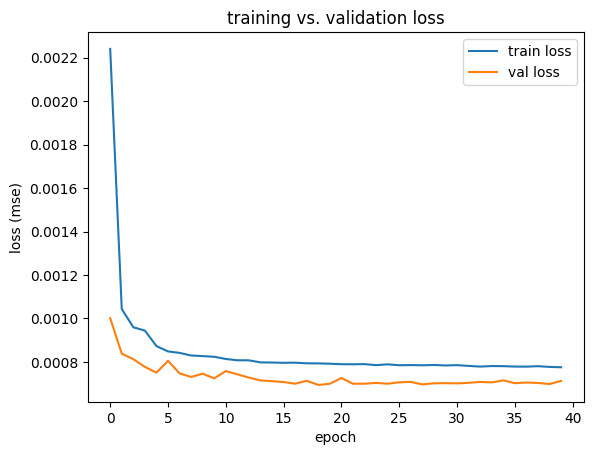

In [22]:
# plot train vs test accuracy
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss (mse)")
plt.legend()
plt.title("training vs. validation loss")
plt.show()

In [ ]:
# try a more robust model (lstm)

# helper to build sequences for lsmt input
feature_cols = ["1d_log_return", "5d_log_return", "rsi", "5d_volatility", "relvol"]
def make_sequences(df, ticker, feature_cols):
    stock_df = df[df["ticker"] == ticker].sort_values("date")
    X, y, dates = [], [], []
    values = stock_df[feature_cols].values
    targets = stock_df["target_next_ret"].values
    for i in range(10, len(stock_df)):
        X.append(values[i-10:i])       # last `window` days of features
        y.append(targets[i-1])             # target aligned with the last day in the window
        dates.append(stock_df["date"].iloc[i-1])
    return np.array(X), np.array(y), dates

# create sequences
all_X, all_y, all_dates = [], [], []
for t in it_sector_cp:
    X_t, y_t, dates_t = make_sequences(df, t, feature_cols)
    all_X.append(X_t)
    all_y.append(y_t)
    all_dates.extend(dates_t)

X = np.concatenate(all_X)
y = np.concatenate(all_y)

model = keras.Sequential([
    keras.layers.LSTM(24, input_shape=(10, len(feature_cols))),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)   
])

model.compile(optimizer="adam", loss="mse")